16:45:03  INFO      Loading observations from .mat file
16:45:03  INFO        Observations restricted to ≤ 2020-12-01
16:45:03  INFO        Period: 2002-01 to 2020-12
16:45:03  INFO        FWT valid: 220/228, range -98.3 to 4.8 mSv (raw sign)
16:45:03  INFO        D345 valid: 220/228, range 84.5 to 183.8 m
16:45:03  INFO      Loading GLORYS12...
16:45:06  INFO        395 timesteps: 1993-01 to 2025-11
16:45:06  INFO          1993-01 (1/395)
16:45:06  INFO      GLORYS dz thicknesses (first 10 levels):
16:45:06  INFO        level   0: centre=    0.49 m, thickness=  1.0177 m
16:45:06  INFO        level   1: centre=    1.54 m, thickness=  1.0758 m
16:45:06  INFO        level   2: centre=    2.65 m, thickness=  1.1391 m
16:45:06  INFO        level   3: centre=    3.82 m, thickness=  1.2163 m
16:45:06  INFO        level   4: centre=    5.08 m, thickness=  1.3106 m
16:45:06  INFO        level   5: centre=    6.44 m, thickness=  1.4257 m
16:45:06  INFO        level   6: centre=    7.93 m, thick

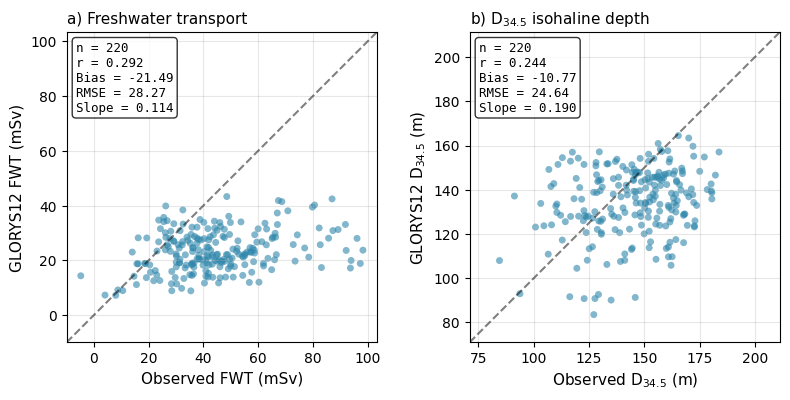

16:48:37  INFO      Complete


In [1]:
"""
Fram Strait Freshwater Transport & D345 Isohaline Depth — 2-panel figure (S4)
=============================================================================
Panel (a): FWT scatter (GLORYS12 vs observations)
Panel (b): D345 isohaline depth scatter (GLORYS12 vs observations)

Observational dataset: FW_2002_2024_345_DGRID3_V6.mat
  - FWT_EGC_345: freshwater transport (mSv, sign flipped → positive = into Greenland Sea)
  - D345_mean:   mean depth of S=34.5 isohaline (m)
  - sref = 34.5 psu
  - Extent: -8 to -2°E, 78.9°N

Note: Observations restricted to ≤ December 2020 (more recent data unpublished).
Sign convention: FWT positive into Greenland Sea (sign flipped relative to raw dataset).

Version:       2.0.0
Last Modified: 22-06-2026
Author:        Chris Barrell
"""

import logging
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import scipy.io as sio
from datetime import datetime, timedelta
from scipy import stats as scipy_stats
import os


def setup_logger(name, log_dir):
    os.makedirs(log_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_path = os.path.join(log_dir, f"{name}_{timestamp}.log")
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    fmt = logging.Formatter("%(asctime)s  %(levelname)-8s  %(message)s", datefmt="%H:%M:%S")
    fh = logging.FileHandler(log_path)
    fh.setFormatter(fmt)
    ch = logging.StreamHandler()
    ch.setFormatter(fmt)
    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger

# ============================================================================
# CONFIGURATION
# ============================================================================

MAT_FILE    = '/local/jbj13rpu/Documents/ROVER/from_laura/FW_2002_2024_345_DGRID3_V6/FW_2002_2024_345_DGRID3_V6.mat'
GLORYS_PATH = '../../glorys12/glorys12_*_Greenland_Sea_deep.nc'
OUTPUT_DIR         = './outputs/figures/'
CSV_DIR            = './outputs/processed_data/figure_s04_FS_FWT/'

LOG_DIR            = './outputs/logs/'
OUTPUT_METHODS_DIR = './outputs/methods/'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(OUTPUT_METHODS_DIR, exist_ok=True)


REPROCESS = False


log = setup_logger("figure_s04_FS_FWT_GLORYS12_verification", LOG_DIR)

LAT_TRANSECT = 78.9
LON_MIN      = -8.0
LON_MAX      = -2.0
S_REF        = 34.5

# Observation cutoff: restrict to data available for publication
OBS_END = '2020-12-01'

COLOR_GLORYS  = '#2E86AB'   # GLORYS blue — consistent with profile validation figures
COLOR_OBS     = 'black'     # Observations — consistent with profile validation figures
COLOR_SCATTER = '#2E86AB'   # Scatter dots — consistent with sea ice verification figures

CSV_FWT_FULL   = CSV_DIR + 'glorys_fwt_full_timeseries.csv'
CSV_FWT_COMP   = CSV_DIR + 'glorys_obs_fwt_comparison.csv'
CSV_D345_FULL  = CSV_DIR + 'd345_isohaline_depth_glorys_full.csv'
CSV_D345_COMP  = CSV_DIR + 'd345_isohaline_depth_comparison.csv'

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def matlab_datenum_to_datetime(datenum):
    return datetime(1, 1, 1) + timedelta(days=int(datenum) - 367)


def remove_nan_pairs(arr1, arr2):
    if hasattr(arr1, 'values'):
        arr1 = arr1.values
    if hasattr(arr2, 'values'):
        arr2 = arr2.values
    arr1 = np.asarray(arr1, dtype=float)
    arr2 = np.asarray(arr2, dtype=float)
    valid = ~(np.isnan(arr1) | np.isnan(arr2))
    return arr1[valid], arr2[valid]


def comparison_stats(obs, model):
    obs_c, model_c = remove_nan_pairs(obs, model)
    if len(obs_c) < 2:
        return None
    corr, p_corr = scipy_stats.pearsonr(obs_c, model_c)
    slope, _, r_val, _, _ = scipy_stats.linregress(obs_c, model_c)
    return {
        'n':             len(obs_c),
        'correlation':   corr,
        'p_correlation': p_corr,
        'bias':          np.mean(model_c - obs_c),
        'rmse':          np.sqrt(np.mean((model_c - obs_c)**2)),
        'slope':         slope,
        'r_squared':     r_val**2,
    }


def calculate_glorys_fwt(ds_glorys, lat_target, lon_min, lon_max, time_str):
    """FWT = ∫∫ vo × (S_ref - so) / S_ref × dz × dx, masked to so < S_REF."""
    ds = ds_glorys.sel(time=time_str)
    lat_idx = np.argmin(np.abs(ds.latitude.values - lat_target))
    ds_t = ds.sel(
        latitude=ds.latitude.values[lat_idx],
        longitude=slice(lon_min, lon_max)
    )

    vo = ds_t.vo
    so = ds_t.so

    dz = ds_t.depth.values
    n = len(dz)
    midpoints = 0.5 * (dz[:-1] + dz[1:])
    dz_thickness = np.zeros(n)
    dz_thickness[0]    = midpoints[0]
    dz_thickness[1:-1] = midpoints[1:] - midpoints[:-1]
    dz_thickness[-1]   = dz[-1] - midpoints[-1]

    if not hasattr(calculate_glorys_fwt, '_printed'):
        calculate_glorys_fwt._printed = True
        log.info("GLORYS dz thicknesses (first 10 levels):")
        for i in range(min(10, n)):
            log.info(f"  level {i:>3}: centre={dz[i]:>8.2f} m, thickness={dz_thickness[i]:>8.4f} m")
        log.info(f"  Total depth: {dz_thickness.sum():.2f} m")

    lat_rad = np.radians(lat_target)
    lon_vals = ds_t.longitude.values
    dx = np.abs(lon_vals[1] - lon_vals[0]) * 111000 * np.cos(lat_rad)

    fw_mask    = (so < S_REF).astype(float)
    fw_density = vo * (S_REF - so) / S_REF * fw_mask

    dz_da = xr.DataArray(dz_thickness, dims=['depth'], coords={'depth': dz})
    fwt = (fw_density * dz_da).sum(dim='depth')
    fwt = (fwt * dx).sum(dim='longitude')

    return float(fwt.values) / 1e3


def glorys_d345(ds_glorys, lat_target, lon_min, lon_max, time_str):
    """Mean depth of S=34.5 isohaline across the transect, via linear interpolation."""
    ds = ds_glorys.sel(time=time_str)
    lat_idx = np.argmin(np.abs(ds.latitude.values - lat_target))
    ds_t = ds.sel(
        latitude=ds.latitude.values[lat_idx],
        longitude=slice(lon_min, lon_max)
    )

    so     = ds_t.so.values
    depths = ds_t.depth.values

    isohaline_depths = []
    for i_lon in range(so.shape[1]):
        profile = so[:, i_lon]
        idx = np.where(profile >= S_REF)[0]
        if len(idx) == 0:
            isohaline_depths.append(np.nan)
        else:
            fi = idx[0]
            if fi == 0:
                isohaline_depths.append(depths[0])
            else:
                frac = (S_REF - profile[fi-1]) / (profile[fi] - profile[fi-1])
                isohaline_depths.append(depths[fi-1] + frac * (depths[fi] - depths[fi-1]))

    valid = [d for d in isohaline_depths if not np.isnan(d)]
    return np.mean(valid) if valid else np.nan


# ============================================================================
# LOAD OBSERVATIONS — restricted to ≤ OBS_END
# ============================================================================

log.info("Loading observations from .mat file")
mat = sio.loadmat(MAT_FILE, squeeze_me=True, struct_as_record=False)

obs_times = pd.to_datetime([
    matlab_datenum_to_datetime(dn) for dn in mat['time']
]).to_period('M').to_timestamp()

fwt_obs  = mat['FWT_EGC_345'].astype(float)
d345_obs = mat['D345_mean'].astype(float)

df_obs = pd.DataFrame({
    'fwt_obs':  fwt_obs,
    'd345_obs': d345_obs
}, index=obs_times)

# Restrict observations to published period only
df_obs = df_obs[df_obs.index <= OBS_END]
log.info(f"  Observations restricted to ≤ {OBS_END}")
log.info(f"  Period: {df_obs.index[0].strftime('%Y-%m')} to {df_obs.index[-1].strftime('%Y-%m')}")
log.info(f"  FWT valid: {df_obs['fwt_obs'].notna().sum()}/{len(df_obs)}, "
         f"range {df_obs['fwt_obs'].min():.1f} to {df_obs['fwt_obs'].max():.1f} mSv (raw sign)")
log.info(f"  D345 valid: {df_obs['d345_obs'].notna().sum()}/{len(df_obs)}, "
         f"range {df_obs['d345_obs'].min():.1f} to {df_obs['d345_obs'].max():.1f} m")

# ============================================================================
# GLORYS: CALCULATE OR LOAD
# ============================================================================

need_fwt  = REPROCESS or not os.path.exists(CSV_FWT_FULL)
need_d345 = REPROCESS or not os.path.exists(CSV_D345_FULL)

if need_fwt or need_d345:
    log.info("Loading GLORYS12...")
    ds_glorys = xr.open_mfdataset(GLORYS_PATH, parallel=False)
    glorys_times = pd.to_datetime(ds_glorys.time.values)
    log.info(f"  {len(glorys_times)} timesteps: "
             f"{glorys_times[0].strftime('%Y-%m')} to {glorys_times[-1].strftime('%Y-%m')}")

    fwt_g, d345_g = [], []

    for i, gtime in enumerate(glorys_times):
        if i % 24 == 0:
            log.info(f"    {gtime.strftime('%Y-%m')} ({i+1}/{len(glorys_times)})")
        ts = gtime.strftime('%Y-%m-01')

        if need_fwt:
            try:
                fwt_g.append(calculate_glorys_fwt(ds_glorys, LAT_TRANSECT, LON_MIN, LON_MAX, ts))
            except Exception as e:
                log.warning(f"    FWT error at {ts}: {e}")
                fwt_g.append(np.nan)

        if need_d345:
            try:
                d345_g.append(glorys_d345(ds_glorys, LAT_TRANSECT, LON_MIN, LON_MAX, ts))
            except Exception as e:
                log.warning(f"    D345 error at {ts}: {e}")
                d345_g.append(np.nan)

    ds_glorys.close()

    if need_fwt:
        pd.DataFrame({'time': glorys_times, 'fwt_glorys': fwt_g}).to_csv(CSV_FWT_FULL, index=False)
        log.info(f"  Saved: {CSV_FWT_FULL}")
    if need_d345:
        pd.DataFrame({'time': glorys_times, 'd345_glorys': d345_g}).to_csv(CSV_D345_FULL, index=False)
        log.info(f"  Saved: {CSV_D345_FULL}")

# Load CSVs (cached; sign flip applied at collocate/plot stage, not in CSV)
log.info("Loading cached GLORYS data")
df_fwt_g  = pd.read_csv(CSV_FWT_FULL,  parse_dates=['time'])
df_d345_g = pd.read_csv(CSV_D345_FULL, parse_dates=['time'])

# ============================================================================
# COLLOCATE FOR SCATTER
# ============================================================================

def collocate(df_obs_col, df_glorys, glorys_col):
    """Match obs and GLORYS by month."""
    g_idx = df_glorys.set_index(
        pd.to_datetime(df_glorys['time']).dt.to_period('M').dt.to_timestamp()
    )
    records = []
    for t, val in df_obs_col.items():
        if np.isnan(val):
            continue
        if t in g_idx.index:
            g_val = g_idx.loc[t, glorys_col]
            if not np.isnan(g_val):
                records.append({'time': t, 'obs': val, 'glorys': g_val})
    return pd.DataFrame(records)

df_fwt_comp  = collocate(df_obs['fwt_obs'],  df_fwt_g,  'fwt_glorys')
df_d345_comp = collocate(df_obs['d345_obs'], df_d345_g, 'd345_glorys')

# Apply sign flip to FWT: raw convention is negative = southward (into Greenland Sea);
# flip so that positive = into Greenland Sea, consistent with paper convention.
df_fwt_comp['obs']    = -df_fwt_comp['obs']
df_fwt_comp['glorys'] = -df_fwt_comp['glorys']

df_fwt_comp.to_csv(CSV_FWT_COMP,  index=False)
df_d345_comp.to_csv(CSV_D345_COMP, index=False)
log.info(f"  FWT collocated pairs:  {len(df_fwt_comp)}")
log.info(f"  D345 collocated pairs: {len(df_d345_comp)}")

stats_fwt  = comparison_stats(df_fwt_comp['obs'],  df_fwt_comp['glorys'])
stats_d345 = comparison_stats(df_d345_comp['obs'], df_d345_comp['glorys'])

# ============================================================================

# ============================================================================
# METHODS OUTPUT
# ============================================================================

def write_methods(stats_fwt, stats_d345):
    """Write methods summary to OUTPUT_METHODS_DIR."""
    fname = os.path.join(OUTPUT_METHODS_DIR, "figure_s04_FS_FWT_GLORYS12_verification_methods.md")
    with open(fname, "w") as f:
        f.write("# Figure S04 — Methods\n\n")
        f.write("## Data sources\n\n")
        f.write(f"Observations: {MAT_FILE}\n")
        f.write(f"Observation cutoff: {OBS_END}\n")
        f.write(f"GLORYS12: {GLORYS_PATH}\n\n")
        f.write("## Transect geometry\n\n")
        f.write(f"Latitude: {LAT_TRANSECT}°N, Longitude: {LON_MIN}° to {LON_MAX}°E\n")
        f.write(f"S_ref = {S_REF} psu\n\n")
        f.write("## FWT verification statistics\n\n")
        if stats_fwt:
            f.write(f"n = {stats_fwt['n']}\n")
            f.write(f"Pearson r = {stats_fwt['correlation']:.3f} (p = {stats_fwt['p_correlation']:.4f})\n")
            f.write(f"Bias = {stats_fwt['bias']:.2f} mSv\n")
            f.write(f"RMSE = {stats_fwt['rmse']:.2f} mSv\n")
            f.write(f"Slope = {stats_fwt['slope']:.3f}\n\n")
        f.write("## D345 verification statistics\n\n")
        if stats_d345:
            f.write(f"n = {stats_d345['n']}\n")
            f.write(f"Pearson r = {stats_d345['correlation']:.3f} (p = {stats_d345['p_correlation']:.4f})\n")
            f.write(f"Bias = {stats_d345['bias']:.2f} m\n")
            f.write(f"RMSE = {stats_d345['rmse']:.2f} m\n")
            f.write(f"Slope = {stats_d345['slope']:.3f}\n")
    log.info(f"Methods written: {fname}")

# FIGURE — 1 × 2 scatter panels only
# ============================================================================

log.info("Creating 2-panel scatter figure")

fig, (ax_fwt_sc, ax_d345_sc) = plt.subplots(1, 2, figsize=(8, 4))

# --------------------------------------------------------------------------
# Helper: scatter panel
# --------------------------------------------------------------------------
def scatter_panel(ax, obs, glorys, stats, xlabel, ylabel, title,
                  invert=False, stats_loc='bottom_right'):
    obs_c, glo_c = remove_nan_pairs(obs, glorys)
    ax.scatter(obs_c, glo_c, c=COLOR_SCATTER, s=25, alpha=0.6, edgecolors='none')

    all_v = np.concatenate([obs_c, glo_c])
    if invert:
        lim_min = np.nanmin(all_v) * 0.85
        lim_max = np.nanmax(all_v) * 1.15
    else:
        margin = 0.05 * (np.nanmax(all_v) - np.nanmin(all_v))
        lim_min = np.nanmin(all_v) - margin
        lim_max = np.nanmax(all_v) + margin
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1.5, alpha=0.5)
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    if stats:
        txt = (f'n = {stats["n"]}\n'
               f'r = {stats["correlation"]:.3f}\n'
               f'Bias = {stats["bias"]:.2f}\n'
               f'RMSE = {stats["rmse"]:.2f}\n'
               f'Slope = {stats["slope"]:.3f}')
        if stats_loc == 'bottom_right':
            ax.text(0.97, 0.05, txt, transform=ax.transAxes, fontsize=9,
                    verticalalignment='bottom', horizontalalignment='right',
                    family='monospace',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:  # top_left
            ax.text(0.03, 0.97, txt, transform=ax.transAxes, fontsize=9,
                    verticalalignment='top', horizontalalignment='left',
                    family='monospace',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=11, loc='left')

# --------------------------------------------------------------------------
# Panel (a): FWT scatter
# --------------------------------------------------------------------------
scatter_panel(
    ax_fwt_sc,
    df_fwt_comp['obs'], df_fwt_comp['glorys'], stats_fwt,
    xlabel='Observed FWT (mSv)', ylabel='GLORYS12 FWT (mSv)',
    title='a) Freshwater transport',stats_loc='top_left'
)

# --------------------------------------------------------------------------
# Panel (b): D345 scatter
# --------------------------------------------------------------------------
scatter_panel(
    ax_d345_sc,
    df_d345_comp['obs'], df_d345_comp['glorys'], stats_d345,
    xlabel='Observed D$_{34.5}$ (m)', ylabel='GLORYS12 D$_{34.5}$ (m)',
    title='b) D$_{34.5}$ isohaline depth',
    invert=True, stats_loc='top_left'
)

plt.tight_layout(w_pad=2.0)

out_path = OUTPUT_DIR + 'figure_s04_FS_FWT_GLORYS12_verification.png'
write_methods(stats_fwt, stats_d345)
fig.savefig(out_path, dpi=600, bbox_inches='tight')
log.info(f"Saved: {out_path}")
plt.show()
log.info("Complete")